In [214]:
import meshio
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

#Konstanter
a0 = 0.01   # m
k = 10**2    # N/m 
K = 10**4    # N/m
B = 1    # m
kappa = k / B

E_analytisk = 8 * kappa / np.sqrt(3)
v_analytisk = 1 / 3


#Lesing av mesh fra fil
def read_mesh(lx0, ly0, n_target):
    mesh  = meshio.read(f"meshes/mesh_Lx{lx0}_Ly{ly0}_Ntarget{n_target}.vtk")
    xy    = mesh.points[:, :2]
    edges = mesh.cells_dict["line"]
    return xy, edges

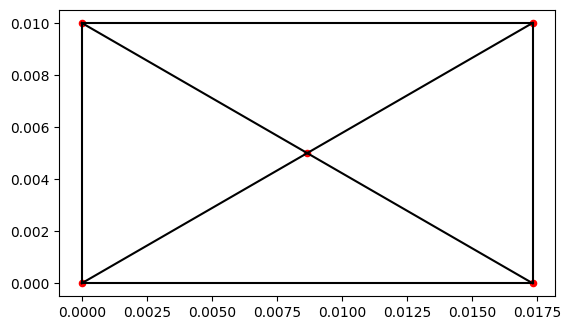

[0.01732051 0.01       0.01       0.01       0.01       0.01
 0.01       0.01732051]


In [215]:
#Oppgave 2:
def make_simple_mesh(a0):
    b0 = np.sqrt(3) * a0
    xy = np.array([
        [0,    0   ],
        [b0,   0   ],
        [b0/2, a0/2],
        [0,    a0  ],
        [b0,   a0  ],
    ])
    edges = np.array([
        [0, 1],
        [0, 2],
        [0, 3],
        [1, 2],
        [1, 4],
        [2, 3],
        [2, 4],
        [3, 4],
    ])
    return xy, edges


def plot_mesh(xy, edges):
    fig, ax = plt.subplots(1, 1)
    for edge in edges:
        ax.plot(xy[edge, 0], xy[edge, 1], 'k')
    ax.scatter(xy[:, 0], xy[:, 1], s=20, color='red')
    ax.set_aspect("equal")
    plt.show()


xy0, edges = make_simple_mesh(a0)
plot_mesh(xy0, edges)

#Beregner hvilelengden til hver fjær
ell0 = np.linalg.norm(xy0[edges[:, 0]] - xy0[edges[:, 1]], axis=1)
print(ell0)

In [216]:
#Oppgave 3: 
def spring_energy(xy, edges, k, ell0):
    energy = 0.0
    for edge, l0 in zip(edges, ell0):
        i, j  = edge
        rij   = xy[j] - xy[i]
        ell   = np.linalg.norm(rij)
        energy += 0.5 * k * (ell - l0) ** 2
    return energy

# Bare sjekker at dette blir 0
print(spring_energy(xy0, edges, k, ell0))

def spring_forces(xy, edges, k, ell0):
    forces = np.zeros_like(xy)
    for edge, l0 in zip(edges, ell0):
        i, j = edge
        rij  = xy[j] - xy[i]
        ell  = np.linalg.norm(rij)
        if ell > 0:
            f_mag = k * (ell - l0)
            f_vec = f_mag * (rij / ell)
            forces[i, :] += f_vec
            forces[j, :] -= f_vec
    return forces

0.0


In [217]:
# Oppgave 4:
lx0 = np.sqrt(3) * a0
ly0 = a0

ids_left = xy0[:, 0] < 1e-12
ids_right = xy0[:, 0] > lx0 - 1e-12
ids_bottom = xy0[:, 1] < 1e-12
ids_top  = xy0[:, 1] > ly0 - 1e-12


def total_energy(xy_flat, edges, k, K, ell0, lx_plate):
    xy = xy_flat.reshape((-1, 2))
    #Energi lagret i orginal-systemet
    energy = spring_energy(xy, edges, k, ell0)
    # Potensiell energi lagret i klamme på venstre side
    energy += 0.5 * K * ((xy[ids_left,  0]) ** 2).sum()
    # Potensiell energi lagret i klamme på høyre side
    energy += 0.5 * K * ((xy[ids_right, 0] - lx_plate) ** 2).sum()
    # Klamme som hindrer massesenteret fra å flytte seg i y-retning
    energy += 0.5 * K * ((xy[ids_left,  1] - xy0[ids_left,  1]).mean() ** 2)
    energy += 0.5 * K * ((xy[ids_right, 1] - xy0[ids_right, 1]).mean() ** 2)
    return energy

       f |         Lx |         Ly |      E_sim |      v_sim
   0.100 |     0.0190 |     0.0097 |   468.7548 |     0.3121


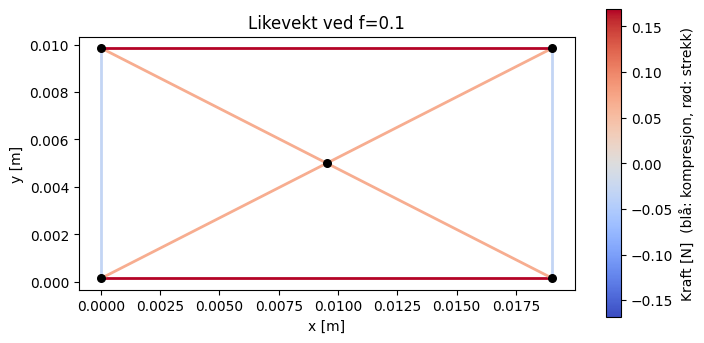

   0.200 |     0.0207 |     0.0094 |   474.5048 |     0.2919


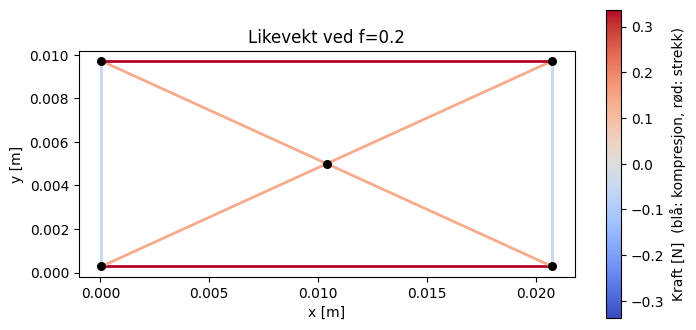

   0.300 |     0.0224 |     0.0092 |   479.3147 |     0.2733


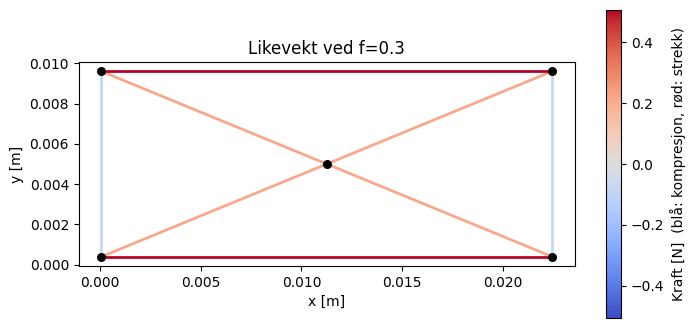

In [218]:
# Oppgave 5:
def total_energy_jacobian(xy_flat, edges, k, K, ell0, lx_plate):
    xy = xy_flat.reshape((-1, 2))
    grad = -spring_forces(xy, edges, k, ell0)
    grad[ids_left, 0] += K * xy[ids_left, 0]
    grad[ids_right, 0] += K * (xy[ids_right, 0] - lx_plate)
    grad[ids_left, 1] += K * (xy[ids_left,  1] - xy0[ids_left,  1]).mean()
    grad[ids_right, 1] += K * (xy[ids_right, 1] - xy0[ids_right, 1]).mean()
    return grad.flatten()


def plot_equilibrium(xy, edges, k, ell0, title="Likevekt"):
    fig, ax = plt.subplots(figsize=(8, 4))

    p1 = xy[edges[:, 0]]
    p2 = xy[edges[:, 1]]
    current_lengths = np.linalg.norm(p1 - p2, axis=1)

    # Positiv verdi = strekk (rød), negativ = kompresjon (blå)
    forces = k * (current_lengths - ell0)
    max_f = np.max(np.abs(forces)) if np.max(np.abs(forces)) > 1e-10 else 1.0

    for i, edge in enumerate(edges):
        color = plt.cm.coolwarm(0.5 + 0.5 * forces[i] / max_f)
        ax.plot(xy[edge, 0], xy[edge, 1], color=color, lw=2)

    ax.scatter(xy[:, 0], xy[:, 1], s=30, color='black', zorder=3)
    ax.set_aspect("equal")
    ax.set_title(title)
    ax.set_xlabel("x [m]")
    ax.set_ylabel("y [m]")

    sm = plt.cm.ScalarMappable(
        cmap=plt.cm.coolwarm,
        norm=plt.Normalize(-max_f, max_f),
    )
    plt.colorbar(sm, ax=ax, label="Kraft [N]  (blå: kompresjon, rød: strekk)")
    plt.show()


#Ulike strekkfaktorer - 10%, 20%, 30%
f_values = [0.1, 0.2, 0.3]

print(f"{'f':>8} | {'Lx':>10} | {'Ly':>10} | {'E_sim':>10} | {'v_sim':>10}")

for f in f_values:
    lx_plate = lx0 * (1 + f)

    res = minimize(
        total_energy,
        xy0.flatten(),
        args=(edges, k, K, ell0, lx_plate),
        method='Newton-CG',
        jac=total_energy_jacobian,
        tol=1e-12,
    )

    xy = res.x.reshape((-1, 2))
    lx = xy[ids_right, 0].mean() - xy[ids_left,  0].mean()
    ly = xy[ids_top,   1].mean() - xy[ids_bottom, 1].mean()

    fn = -K * (xy[ids_right, 0] - lx_plate).sum()
    eps_n = (lx - lx0) / lx0
    eps_t = (ly - ly0) / ly0
    sigma = fn / (ly0 * B)

    e_sim = sigma / eps_n
    v_sim = -eps_t / eps_n

    print(f"{f:8.3f} | {lx:10.4f} | {ly:10.4f} | {e_sim:10.4f} | {v_sim:10.4f}")

    plot_equilibrium(xy, edges, k, ell0, title=f"Likevekt ved f={f}")

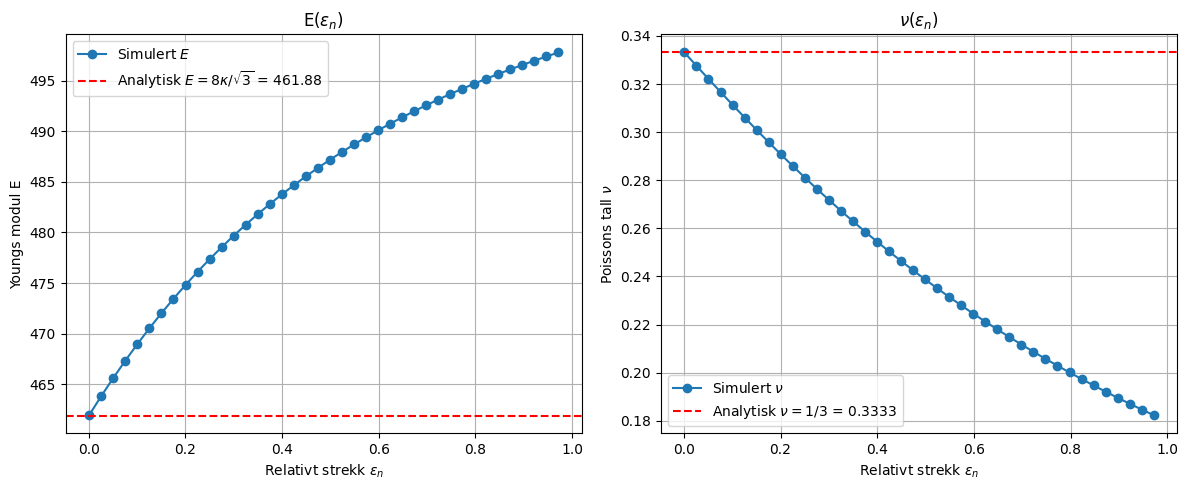

In [219]:
# Oppgave 6: Mål E og v som funksjon av epsilon_n

f_values = np.linspace(0.001, 1, 40) #40 punkter mellom 0.001 og 1

eps_n_list = [] #epsilon_n
E_sim_list = [] #Youngs modul
v_sim_list = [] #Poissons tall

for f in f_values:
    lx_plate = lx0 * (1 + f)

    res = minimize(
        total_energy,
        xy0.flatten(),
        args=(edges, k, K, ell0, lx_plate),     #Finner energiminimumet og lagrer koordiatene i res.x inni res-"biblioteket"
        method='Newton-CG',
        jac=total_energy_jacobian,
        tol=1e-12,
        options={'maxiter': 1000},
    )

    xy_eq = res.x.reshape((-1, 2)) #En N*2 koordinat-array når systemet er i likevekt
    lx = xy_eq[ids_right, 0].mean() - xy_eq[ids_left, 0].mean()
    ly = xy_eq[ids_top, 1].mean() - xy_eq[ids_bottom, 1].mean()

    fn = -K * (xy_eq[ids_right, 0] - lx_plate).sum()
    eps_n = (lx - lx0) / lx0
    eps_t = (ly - ly0) / ly0
    sigma = fn / (ly0 * B)

    eps_n_list.append(eps_n)
    E_sim_list.append(sigma / eps_n)
    v_sim_list.append(-eps_t / eps_n)

eps_n_arr = np.array(eps_n_list)
E_sim_arr = np.array(E_sim_list)
v_sim_arr = np.array(v_sim_list)

# Plot Young som funksjon av epsilon_n
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(eps_n_arr, E_sim_arr, 'o-', label='Simulert $E$')
ax1.axhline(E_analytisk, color='red', linestyle='--',
            label=f'Analytisk $E = 8\\kappa/\\sqrt{{3}}$ = {E_analytisk:.2f}')
ax1.set_xlabel('Relativt strekk $\\varepsilon_n$')
ax1.set_ylabel('Youngs modul E')
ax1.set_title("E($\\varepsilon_n$)")
ax1.legend()
ax1.grid(True)

# Plot Poisson som funksjon av epsilon_n
ax2.plot(eps_n_arr, v_sim_arr, 'o-', label="Simulert $\\nu$")
ax2.axhline(v_analytisk, color='red', linestyle='--',
            label=f'Analytisk $\\nu = 1/3$ = {v_analytisk:.4f}')
ax2.set_xlabel('Relativt strekk $\\varepsilon_n$')
ax2.set_ylabel("Poissons tall $\\nu$")
ax2.set_title("$\\nu$($\\varepsilon_n$)")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()



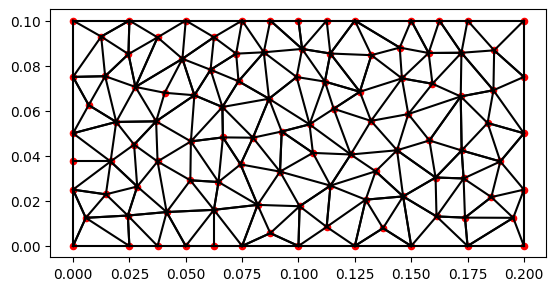

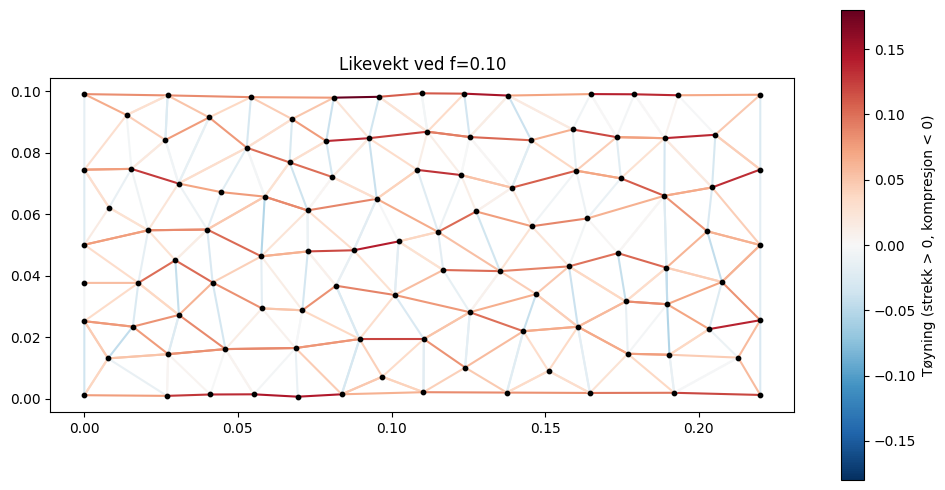

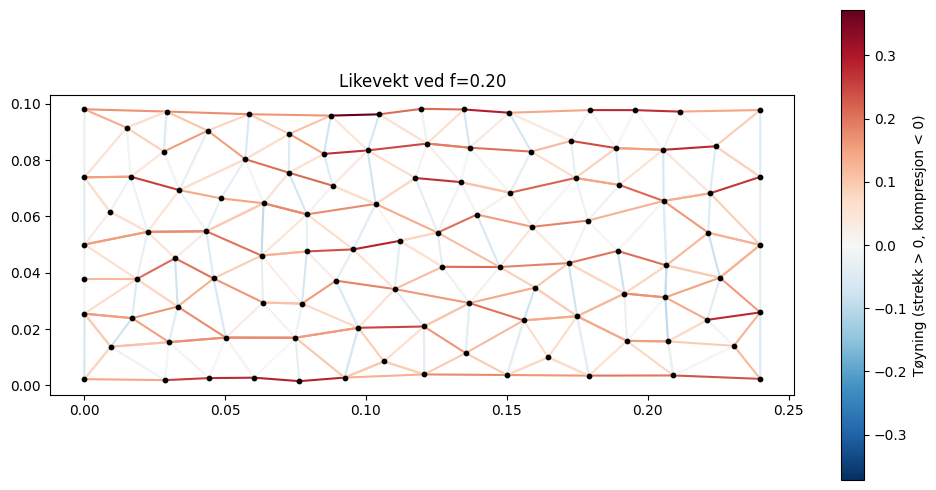

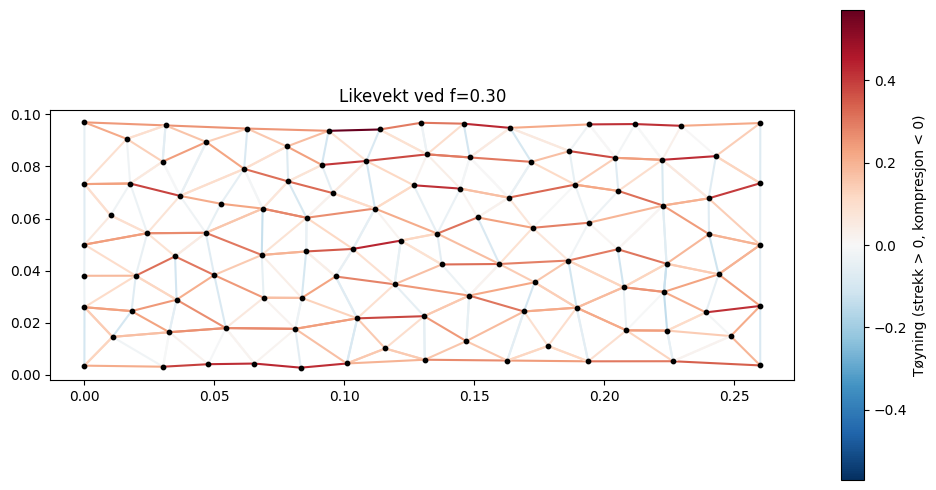

/var/folders/ld/048wvw6d52q09nps8g4l947r0000gn/T/ipykernel_51843/2583587498.py:122: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend()
/var/folders/ld/048wvw6d52q09nps8g4l947r0000gn/T/ipykernel_51843/2583587498.py:127: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend()


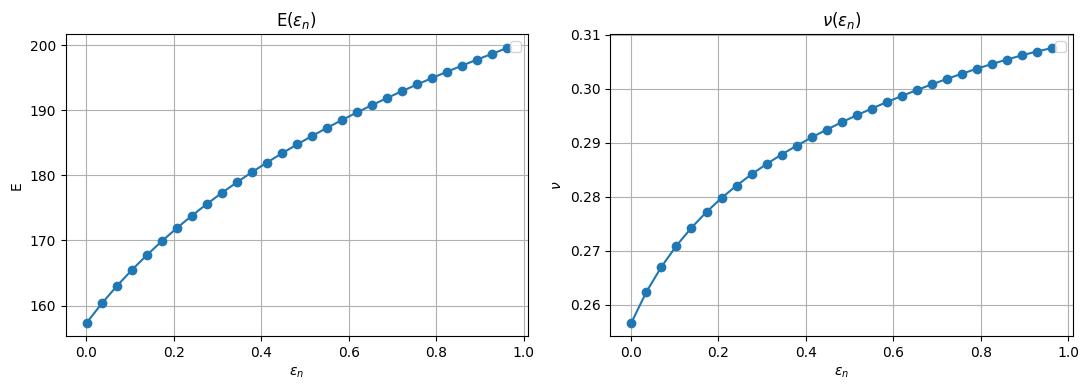

In [220]:
# Oppgave 7 del 1: Vi gjenbruker det meste av kode

N = 100
lx0  = 0.2 # m
ly0  = 0.1 # m

xy0, edges = read_mesh(lx0, ly0, N)
ell0 = np.linalg.norm(xy0[edges[:, 0]] - xy0[edges[:, 1]], axis=1)

ids_left = xy0[:, 0] < 1e-10
ids_right = xy0[:, 0] > lx0 - 1e-10
ids_bottom = xy0[:, 1] < 1e-10
ids_top = xy0[:, 1] > ly0 - 1e-10

plot_mesh(xy0, edges)

def spring_energy(xy, edges, k, ell0):
    dr = xy[edges[:, 1]] - xy[edges[:, 0]]     #dr blir en N*2 array hvor radene er vektoren mellom nodene i meshet
    ell = np.linalg.norm(dr, axis=1)            
    return 0.5 * k * np.sum((ell - ell0)**2)

def spring_forces(xy, edges, k, ell0):
    forces = np.zeros_like(xy)
    dr = xy[edges[:, 1]] - xy[edges[:, 0]]
    ell = np.linalg.norm(dr, axis=1, keepdims=True)
    f_vec  = k * (ell - ell0[:, None]) * (dr / ell)
    np.add.at(forces, edges[:, 0],  f_vec)
    np.add.at(forces, edges[:, 1], -f_vec)
    return forces

def spring_strains(xy, edges, ell0): #epsilon_n for hver enkelt fjær. Vi bruker den når vi skal fargekode strekk eller komprisjon
    dr = xy[edges[:, 1]] - xy[edges[:, 0]]
    ell = np.linalg.norm(dr, axis=1)
    return (ell - ell0) / ell0

def total_energy(xy_flat, edges, k, K, ell0, lx_plate):
    xy = xy_flat.reshape((-1, 2))
    energy = spring_energy(xy, edges, k, ell0)
    energy += 0.5 * K * (xy[ids_left,  0]**2).sum()
    energy += 0.5 * K * ((xy[ids_right, 0] - lx_plate)**2).sum()
    energy += 0.5 * K * (xy[ids_left,  1] - xy0[ids_left,  1]).mean()**2
    energy += 0.5 * K * (xy[ids_right, 1] - xy0[ids_right, 1]).mean()**2
    return energy

def total_energy_jacobian(xy_flat, edges, k, K, ell0, lx_plate):
    xy = xy_flat.reshape((-1, 2))
    grad = -spring_forces(xy, edges, k, ell0)
    grad[ids_left,  0] += K * xy[ids_left, 0]
    grad[ids_right, 0] += K * (xy[ids_right, 0] - lx_plate)
    grad[ids_left,  1] += K * (xy[ids_left,  1] - xy0[ids_left,  1]).mean()
    grad[ids_right, 1] += K * (xy[ids_right, 1] - xy0[ids_right, 1]).mean()
    return grad.flatten()

MINIMIZE_KWARGS = dict(
    method='Newton-CG',
    jac=total_energy_jacobian,
    tol=1e-6,
    options={'maxiter': 1000}
)

def plot_equilibrium(xy, edges, ell0, title = "likevekt"):
    strains = spring_strains(xy, edges, ell0)
    vmax = np.max(np.abs(strains))

    fig, ax = plt.subplots(figsize=(10, 5))
    sm = plt.cm.ScalarMappable(cmap='RdBu_r',
                                norm=plt.Normalize(vmin=-vmax, vmax=vmax))
    for edge, strain in zip(edges, strains):
        color = sm.cmap(sm.norm(strain))
        ax.plot(xy[edge, 0], xy[edge, 1], color=color, lw=1.5)

    ax.scatter(xy[:, 0], xy[:, 1], s=10, color='k', zorder=5)
    plt.colorbar(sm, ax=ax, label='Tøyning (strekk > 0, kompresjon < 0)')
    ax.set_aspect("equal")
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

#Strekkfaktorer, 10%, 20% og 30%
f_values = [0.1, 0.2, 0.3]

for f in f_values:
    lx_plate = lx0 * (1 + f)
    res = minimize(total_energy, xy0.flatten(),
                   args=(edges, k, K, ell0, lx_plate), **MINIMIZE_KWARGS)
    xy = res.x.reshape((-1, 2))
    plot_equilibrium(xy, edges, ell0, title=f"Likevekt ved f={f:.2f}")

#Oppgave 7 del 2

f_values  = np.linspace(0.001, 1, 30)
eps_n_list = []
E_list = []
v_list = []

for f in f_values[0:29]: #Måtte kutte siste f=1 fordi det avviket ekstremt for en eller annen grunn
    lx_plate = lx0 * (1 + f)
    res = minimize(total_energy, xy0.flatten(),
                   args=(edges, k, K, ell0, lx_plate), **MINIMIZE_KWARGS)
    xy = res.x.reshape((-1, 2))

    lx    = xy[ids_right, 0].mean() - xy[ids_left,   0].mean()
    ly    = xy[ids_top,   1].mean() - xy[ids_bottom,  1].mean()
    eps_n = (lx - lx0) / lx0
    eps_t = (ly - ly0) / ly0
    sigma = -K * (xy[ids_right, 0] - lx_plate).sum() / (ly0 * B)

    eps_n_list.append(eps_n)
    E_list.append(sigma / eps_n)
    v_list.append(-eps_t / eps_n)

eps_n_arr = np.array(eps_n_list)
E_arr = np.array(E_list)
v_arr = np.array(v_list)

#Plot E og v
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

ax1.plot(eps_n_arr, E_arr, 'o-')
ax1.set(xlabel='$\\varepsilon_n$', ylabel='E', title='E($\\varepsilon_n$)')
ax1.grid(True)
ax1.legend()

ax2.plot(eps_n_arr, v_arr, 'o-')
ax2.set(xlabel='$\\varepsilon_n$', ylabel='$\\nu$', title='$\\nu$($\\varepsilon_n$)')
ax2.grid(True)
ax2.legend()

plt.tight_layout()
plt.show()

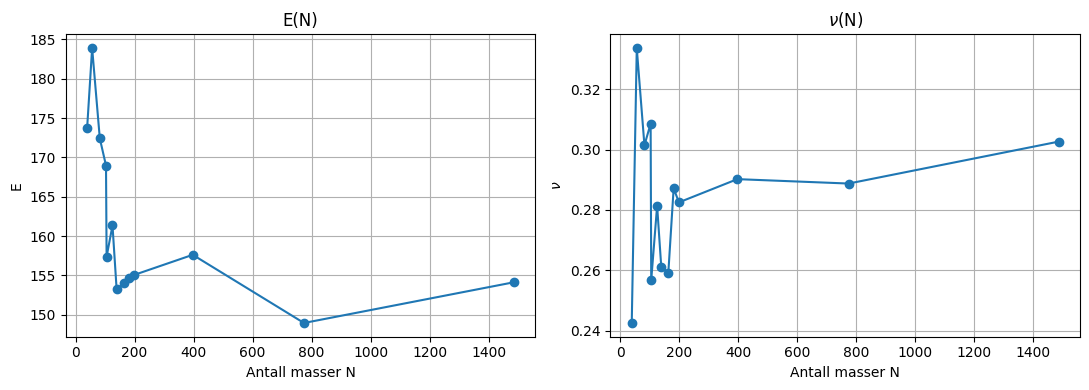

In [221]:
# Oppgave 8:

# Konstanter
N_values = [10, 31, 52, 73, 94, 100, 115, 136, 157, 178, 200, 400, 800, 1600]
f_small = 0.001

lx0 = 0.2  # m
ly0 = 0.1  # m

E_list = []
v_list = []
N_actual_list = []

for N_target in N_values[1:]: #N = [31, 1600]

    xy0, edges = read_mesh(lx0, ly0, N_target)
    ell0 = np.linalg.norm(xy0[edges[:, 0]] - xy0[edges[:, 1]], axis=1)
    N_actual = len(xy0)

    ids_left = xy0[:, 0] < 1e-10
    ids_right  = xy0[:, 0] > lx0 - 1e-10
    ids_bottom = xy0[:, 1] < 1e-10
    ids_top = xy0[:, 1] > ly0 - 1e-10

    lx_plate = lx0 * (1 + f_small)
    res = minimize(
                total_energy, xy0.flatten(),
                args=(edges, k, K, ell0, lx_plate),
                **MINIMIZE_KWARGS)

    xy = res.x.reshape((-1, 2))
    lx = xy[ids_right, 0].mean() - xy[ids_left,   0].mean()
    ly = xy[ids_top,   1].mean() - xy[ids_bottom,  1].mean()
    eps_n = (lx - lx0) / lx0
    eps_t = (ly - ly0) / ly0
    sigma = -K * (xy[ids_right, 0] - lx_plate).sum() / (ly0 * B)

    E_list.append(sigma / eps_n)
    v_list.append(-eps_t / eps_n)
    N_actual_list.append(N_actual)

E_arr = np.array(E_list)
v_arr = np.array(v_list)
N_arr = np.array(N_actual_list)

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

ax1.plot(N_arr, E_arr, 'o-')
ax1.set(xlabel='Antall masser N', ylabel='E', title='E(N)')
ax1.grid(True)

ax2.plot(N_arr, v_arr, 'o-')
ax2.set(xlabel='Antall masser N', ylabel=r'$\nu$', title=r'$\nu$(N)')
ax2.grid(True)

plt.tight_layout()
plt.show()